In [2]:
# ============================================================
# BLOCK 0 — LOAD TABULAR DATASET (inspect before trusting assumptions)
# ============================================================
import numpy as np
import pandas as pd
import os

# from google.colab import drive
# drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/DAI_DSE/dataset"
TABULAR_PATH = f"{DATA_DIR}/dse_final_v3.csv"   # <-- adjust filename to your actual tabular v3 file

df = pd.read_csv(TABULAR_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head())
print("\nDtypes:")
print(df.dtypes)

Shape: (924946, 29)
Columns: ['date', 'trading_code', 'sector', 'instrument_type', 'split', 'daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 'price_gap', 'rolling_5d_volatility', 'rolling_10d_momentum', 'ema_12', 'macd', 'macd_signal', 'macd_hist', 'rsi_14', 'stoch_k', 'stoch_d', 'roc_10', 'bb_width', 'atr_14', 'obv', 'class_same_day', 'class_same_day_alt', 'target_class', 'target_class_alt', '_used_pooled_fallback', '_suspected_corp_action']
         date trading_code     sector instrument_type  split  daily_return  \
0  2017-10-29     AAMRANET  IT Sector          Equity  train     -1.619955   
1  2017-10-30     AAMRANET  IT Sector          Equity  train      1.784849   
2  2017-10-31     AAMRANET  IT Sector          Equity  train      1.560674   
3  2017-11-01     AAMRANET  IT Sector          Equity  train     -1.436048   
4  2017-11-02     AAMRANET  IT Sector          Equity  train      0.476083   

   high_low_spread  intraday_volatility  volume_change

In [3]:
# ============================================================
# BLOCK 0.1-HMM — FEATURES / TARGET / TRAIN-TEST SPLIT (tabular, confirmed)
# Using target_class (primary label) — target_class_alt reserved for a
# later sensitivity-analysis rerun addressing Reviewer 2's threshold-
# stability question, not the main reported result.
# Rows flagged _suspected_corp_action are dropped (1,353 / 924,946 = 0.15%)
# since corporate-action artifacts (splits, bonus shares) can produce
# spurious extreme-return "crash" labels unrelated to genuine market
# stress — worth flagging as a preprocessing step in Methods, given
# Reviewer 4's data-quality concerns.
# ============================================================
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]
missing = [f for f in ALL_FEATURES if f not in df.columns]
assert not missing, f"Missing expected feature columns: {missing}"

CLASS_NAMES = {0: "Normal", 1: "High-Vol", 2: "Crash"}
CRASH_IDX   = 2
LABEL_MAP   = {0: 0, 1: 1, 3: 2}

DROP_CORP_ACTION_ROWS = True
if DROP_CORP_ACTION_ROWS:
    n_before = len(df)
    df_clean = df.loc[~df["_suspected_corp_action"]].reset_index(drop=True)
    print(f"Dropped {n_before - len(df_clean):,} suspected corp-action rows "
          f"({(n_before - len(df_clean)) / n_before:.3%} of data)")
else:
    df_clean = df.copy()

y_raw = df_clean["target_class"].values
y_all = np.vectorize(LABEL_MAP.get)(y_raw)
assert set(np.unique(y_all)) <= {0, 1, 2}, "Unexpected label values after remapping."

df_clean["y"] = y_all
X_all = df_clean[ALL_FEATURES].values.astype(np.float64)

train_mask = (df_clean["split"] == "train").values
test_mask  = (df_clean["split"] == "test").values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

train_meta = df_clean.loc[train_mask, ["trading_code", "date"]].reset_index(drop=True)
test_meta  = df_clean.loc[test_mask,  ["trading_code", "date"]].reset_index(drop=True)

print("Train rows:", X_train.shape, " Test rows:", X_test.shape)
print("Train class balance:", np.round(np.bincount(y_train) / len(y_train), 4))
print("Test  class balance:", np.round(np.bincount(y_test) / len(y_test), 4))

Dropped 1,353 suspected corp-action rows (0.146% of data)
Train rows: (629117, 18)  Test rows: (294476, 18)
Train class balance: [0.7388 0.2059 0.0553]
Test  class balance: [0.738 0.215 0.047]


In [9]:
# ============================================================
# BLOCK 0.2 — EXPANDING-WINDOW WALK-FORWARD CV, WITH EMBARGO (tabular)
# Same fold logic used across your RF/LR/XGB/LSTM/GRU notebooks, so the
# HMM's CV results stay directly comparable for the Friedman/Nemenyi fix.
# ============================================================
def make_expanding_folds(dates_sorted_unique, n_folds=5, embargo_days=5):
    n = len(dates_sorted_unique)
    fold_size = n // (n_folds + 1)
    folds = []
    for k in range(1, n_folds + 1):
        val_start = k * fold_size
        val_end   = min((k + 1) * fold_size, n)
        if val_start >= n or val_end <= val_start:
            continue
        train_end = max(val_start - embargo_days, 1)
        folds.append((dates_sorted_unique[:train_end], dates_sorted_unique[val_start:val_end]))
    return folds

train_meta["date"] = pd.to_datetime(train_meta["date"])
unique_train_dates = np.sort(train_meta["date"].unique())
FOLDS_DATES = make_expanding_folds(unique_train_dates, n_folds=5, embargo_days=5)

train_dates_arr = train_meta["date"].values
cv_splits = []
for i, (tr_d, va_d) in enumerate(FOLDS_DATES):
    tr_idx = np.where(np.isin(train_dates_arr, tr_d))[0]
    va_idx = np.where(np.isin(train_dates_arr, va_d))[0]
    cv_splits.append((tr_idx, va_idx))
    print(f"Fold {i+1}: train {pd.Timestamp(tr_d[0]).date()}->{pd.Timestamp(tr_d[-1]).date()} "
          f"({len(tr_idx):,} rows) | val {pd.Timestamp(va_d[0]).date()}->{pd.Timestamp(va_d[-1]).date()} "
          f"({len(va_idx):,} rows)")

Fold 1: train 2008-04-03->2010-01-11 (80,563 rows) | val 2010-01-19->2011-11-02 (90,518 rows)
Fold 2: train 2008-04-03->2011-10-26 (171,014 rows) | val 2011-11-03->2013-09-02 (97,492 rows)
Fold 3: train 2008-04-03->2013-08-25 (268,399 rows) | val 2013-09-03->2015-06-17 (108,981 rows)
Fold 4: train 2008-04-03->2015-06-10 (377,204 rows) | val 2015-06-18->2017-03-21 (121,366 rows)
Fold 5: train 2008-04-03->2017-03-14 (498,490 rows) | val 2017-03-22->2018-12-20 (127,933 rows)


In [4]:
# ============================================================
# BLOCK 1-GARCH — SETUP
# Model choice: GJR-GARCH(1,1), Student-t innovations.
# - GJR term captures the leverage effect (negative shocks raise volatility
#   more than positive ones) — standard, well-documented in equity markets.
# - Student-t innovations account for fat-tailed daily returns.
# - More numerically stable to estimate than EGARCH's log-variance form.
# GARCH legitimately conditions on past daily_return — this is NOT the same
# leakage issue flagged for the ML classifiers. GARCH's recursive variance
# equation only ever uses r_{t-1}, sigma_{t-1} to produce sigma_t: strictly
# one-step-ahead by construction, so no lookahead risk despite using returns
# directly as the model's core input.
# ============================================================
!pip install arch --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc, time
warnings.filterwarnings("ignore")

from arch import arch_model
from scipy.stats import t as student_t
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, roc_curve, auc, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
MIN_TICKER_OBS = 100   # skip tickers with too little train history to fit reliably

daily_return_idx = ALL_FEATURES.index("daily_return")
train_returns_all = X_train[:, daily_return_idx]
test_returns_all  = X_test[:, daily_return_idx]

train_meta = train_meta.copy()
test_meta  = test_meta.copy()
train_meta["date"] = pd.to_datetime(train_meta["date"])
test_meta["date"]  = pd.to_datetime(test_meta["date"])
train_meta["return"] = train_returns_all
test_meta["return"]  = test_returns_all
train_meta["y"] = y_train
test_meta["y"]  = y_test

tickers = train_meta["trading_code"].unique()
print(f"Total tickers: {len(tickers)}")
print(f"Daily return stats (train): mean={train_returns_all.mean():.4f}, std={train_returns_all.std():.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.1 MB/s eta 0:00:00
Total tickers: 311
Daily return stats (train): mean=-0.0339, std=1.0737


In [5]:
# ============================================================
# BLOCK 2-GARCH — CAUSAL RECURSIVE VARIANCE FILTER
# Rather than relying on arch's forecast() API (which behaves differently
# for multi-step vs. rolling 1-step forecasts), this reimplements the GJR
# recursion manually — same style as the HMM's forward_filter_causal — so
# behavior is fully transparent and consistent across train/test.
# Feeding REALIZED (already-occurred, historical) test returns into the
# recursion is legitimate walk-forward evaluation, not leakage: sigma_t only
# ever depends on r_{t-1}, sigma_{t-1}, both already known at the start of
# day t in a real deployment.
# ============================================================
def gjr_garch_recursive_filter(returns, mu, omega, alpha, gamma, beta, sigma2_init=None):
    """
    returns: 1D array, chronological order for ONE ticker (can span train+test)
    Returns: sigma2 array (conditional variance) of the same length, where
    sigma2[t] depends only on returns[0..t-1].
    """
    n = len(returns)
    sigma2 = np.zeros(n)
    resid = returns - mu

    sigma2[0] = sigma2_init if sigma2_init is not None else np.var(returns)
    for t in range(1, n):
        eps_prev = resid[t-1]
        leverage = gamma * (eps_prev**2) * (1.0 if eps_prev < 0 else 0.0)
        sigma2[t] = omega + alpha * (eps_prev**2) + leverage + beta * sigma2[t-1]
        sigma2[t] = max(sigma2[t], 1e-10)  # numerical floor

    return sigma2

print("Causal GJR-GARCH recursive filter ready.")

Causal GJR-GARCH recursive filter ready.


In [6]:
# ============================================================
# BLOCK 3-GARCH — FIT GJR-GARCH(1,1) PER TICKER (TRAIN ONLY)
# Crash threshold uses the SAME rule as the original label definition
# (mu_train - 2*sigma_train, per ticker) — computed from train returns only,
# per Reviewer 4's leakage requirement. High-vol threshold is a GARCH-native
# proxy (75th percentile of in-sample fitted conditional volatility for that
# ticker) since GARCH models return volatility, not the intraday_volatility
# feature the original label used — flagged explicitly as an approximation.
# ============================================================
ticker_models = {}
skipped_tickers = []

t0 = time.time()
for idx, code in enumerate(tickers):
    sub = train_meta[train_meta["trading_code"] == code].sort_values("date")
    r = sub["return"].values

    if len(r) < MIN_TICKER_OBS:
        skipped_tickers.append(code)
        continue

    try:
        am = arch_model(r, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t")
        res = am.fit(disp="off", show_warning=False)

        mu    = res.params["mu"]
        omega = res.params["omega"]
        alpha = res.params["alpha[1]"]
        gamma = res.params["gamma[1]"]
        beta  = res.params["beta[1]"]
        nu    = res.params["nu"]

        # Stationarity sanity check for GJR-GARCH: alpha + gamma/2 + beta < 1
        persistence = alpha + gamma / 2 + beta
        if not np.isfinite(persistence) or persistence >= 1.0:
            skipped_tickers.append(code)
            continue

        in_sample_sigma2 = res.conditional_volatility ** 2
        crash_threshold = r.mean() - 2 * r.std()
        vol_q75 = np.percentile(np.sqrt(in_sample_sigma2), 75)
        vol_std = np.sqrt(in_sample_sigma2).std() + 1e-9

        ticker_models[code] = {
            "mu": mu, "omega": omega, "alpha": alpha, "gamma": gamma, "beta": beta, "nu": nu,
            "persistence": persistence,
            "crash_threshold": crash_threshold,
            "vol_q75": vol_q75, "vol_std": vol_std,
            "last_sigma2": in_sample_sigma2[-1],
            "n_train_obs": len(r),
        }
    except Exception as e:
        skipped_tickers.append(code)
        continue

    if (idx + 1) % 50 == 0:
        print(f"  fit {idx+1}/{len(tickers)} tickers...")

elapsed = time.time() - t0
print(f"\nFitted {len(ticker_models)} / {len(tickers)} tickers in {elapsed:.0f}s")
print(f"Skipped {len(skipped_tickers)} tickers (insufficient data or non-stationary fit)")

  fit 50/311 tickers...
  fit 100/311 tickers...
  fit 150/311 tickers...
  fit 200/311 tickers...
  fit 250/311 tickers...
  fit 300/311 tickers...

Fitted 300 / 311 tickers in 71s
Skipped 11 tickers (insufficient data or non-stationary fit)


In [7]:
# ============================================================
# BLOCK 4-GARCH — CAUSAL TEST FORECAST + 3-CLASS PROBABILITY VECTOR
# For each ticker, concatenate train+test returns (realized, historical —
# no future values) and run the causal recursion across the full span, then
# slice out the test portion. sigma_t at any test index still depends only
# on returns strictly before it.
# Crash probability: P(r_t < crash_threshold) via the fitted Student-t
# distribution — standard GARCH-VaR tail-risk methodology.
# High-vol probability: soft (logistic) score of how far sigma_t exceeds the
# train-derived volatility threshold, with crash mass subtracted first so
# the two don't double-count.
# ============================================================
all_test_results = []

for code, params in ticker_models.items():
    tr_sub = train_meta[train_meta["trading_code"] == code].sort_values("date")
    te_sub = test_meta[test_meta["trading_code"] == code].sort_values("date")
    if len(te_sub) == 0:
        continue

    full_returns = np.concatenate([tr_sub["return"].values, te_sub["return"].values])
    n_train = len(tr_sub)

    sigma2_full = gjr_garch_recursive_filter(
        full_returns, params["mu"], params["omega"], params["alpha"],
        params["gamma"], params["beta"], sigma2_init=np.var(tr_sub["return"].values)
    )
    sigma2_test = sigma2_full[n_train:]
    sigma_test  = np.sqrt(sigma2_test)

    crash_thr = params["crash_threshold"]
    p_crash = student_t.cdf(crash_thr, df=params["nu"], loc=params["mu"], scale=sigma_test)

    highvol_raw = 1 / (1 + np.exp(-(sigma_test - params["vol_q75"]) / params["vol_std"]))
    p_highvol = highvol_raw * (1 - p_crash)
    p_normal = 1 - p_crash - p_highvol

    proba = np.column_stack([p_normal, p_highvol, p_crash])
    proba = np.clip(proba, 1e-9, 1.0)
    proba = proba / proba.sum(axis=1, keepdims=True)  # renormalize to sum to 1

    for i in range(len(te_sub)):
        all_test_results.append({
            "trading_code": code,
            "date": te_sub["date"].values[i],
            "y_true": te_sub["y"].values[i],
            "p_normal": proba[i, 0],
            "p_highvol": proba[i, 1],
            "p_crash": proba[i, 2],
            "sigma": sigma_test[i],
        })

results_garch = pd.DataFrame(all_test_results).sort_values(["trading_code", "date"]).reset_index(drop=True)
test_proba_garch = results_garch[["p_normal", "p_highvol", "p_crash"]].values
test_pred_garch  = test_proba_garch.argmax(axis=1)
y_test_garch     = results_garch["y_true"].values

print(f"Test rows covered by GARCH: {len(results_garch)} / {len(test_meta)} "
      f"({len(results_garch)/len(test_meta):.1%} — remainder are skipped tickers)")
print("Predicted class distribution:", pd.Series(test_pred_garch).value_counts(normalize=True).round(4).to_dict())

Test rows covered by GARCH: 276322 / 294476 (93.8% — remainder are skipped tickers)
Predicted class distribution: {0: 0.7617, 1: 0.235, 2: 0.0034}


In [10]:
# ============================================================
# BLOCK 5-GARCH — EXPANDING-WINDOW CV
# Refits every ticker's GJR-GARCH per fold — this is the slowest block
# (≈321 tickers × 5 folds ≈ 1,600 fits). Each individual fit is fast
# (well under a second typically), so expect low-to-mid single-digit
# minutes total on CPU, not hours.
# ============================================================
def crash_pr_auc_garch(y_true, y_proba):
    y_bin = (y_true == CRASH_IDX).astype(int)
    return average_precision_score(y_bin, y_proba[:, CRASH_IDX])

fold_metrics_garch = []
fold_val_predictions_garch = []

for fold_i, (tr_idx, va_idx) in enumerate(cv_splits):
    fold_train_meta = train_meta.iloc[tr_idx].copy()
    fold_val_meta   = train_meta.iloc[va_idx].copy()

    fold_results = []
    for code in fold_train_meta["trading_code"].unique():
        tr_sub = fold_train_meta[fold_train_meta["trading_code"] == code].sort_values("date")
        va_sub = fold_val_meta[fold_val_meta["trading_code"] == code].sort_values("date")
        if len(tr_sub) < MIN_TICKER_OBS or len(va_sub) == 0:
            continue

        r = tr_sub["return"].values
        try:
            am = arch_model(r, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t")
            res = am.fit(disp="off", show_warning=False)
            mu, omega = res.params["mu"], res.params["omega"]
            alpha, gamma, beta, nu = res.params["alpha[1]"], res.params["gamma[1]"], res.params["beta[1]"], res.params["nu"]
            persistence = alpha + gamma/2 + beta
            if not np.isfinite(persistence) or persistence >= 1.0:
                continue
        except Exception:
            continue

        in_sample_sigma2 = res.conditional_volatility ** 2
        crash_thr = r.mean() - 2 * r.std()
        vol_q75 = np.percentile(np.sqrt(in_sample_sigma2), 75)
        vol_std = np.sqrt(in_sample_sigma2).std() + 1e-9

        full_r = np.concatenate([r, va_sub["return"].values])
        sigma2_full = gjr_garch_recursive_filter(full_r, mu, omega, alpha, gamma, beta, sigma2_init=np.var(r))
        sigma_va = np.sqrt(sigma2_full[len(r):])

        p_crash = student_t.cdf(crash_thr, df=nu, loc=mu, scale=sigma_va)
        highvol_raw = 1 / (1 + np.exp(-(sigma_va - vol_q75) / vol_std))
        p_highvol = highvol_raw * (1 - p_crash)
        p_normal = 1 - p_crash - p_highvol
        proba = np.clip(np.column_stack([p_normal, p_highvol, p_crash]), 1e-9, 1.0)
        proba = proba / proba.sum(axis=1, keepdims=True)

        for i in range(len(va_sub)):
            fold_results.append({"y_true": va_sub["y"].values[i], "p_normal": proba[i,0],
                                  "p_highvol": proba[i,1], "p_crash": proba[i,2]})

    if not fold_results:
        print(f"Fold {fold_i+1}: no valid ticker fits — skipping fold.")
        continue

    fold_df = pd.DataFrame(fold_results)
    fold_proba = fold_df[["p_normal","p_highvol","p_crash"]].values
    fold_pred = fold_proba.argmax(axis=1)
    fold_y = fold_df["y_true"].values

    fold_metrics_garch.append({
        "fold": fold_i + 1,
        "crash_pr_auc": crash_pr_auc_garch(fold_y, fold_proba),
        "crash_recall": recall_score(fold_y == CRASH_IDX, fold_pred == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(fold_y == CRASH_IDX, fold_pred == CRASH_IDX, zero_division=0),
        "roc_auc_ovr": roc_auc_score(fold_y, fold_proba, multi_class="ovr"),
    })
    fold_val_predictions_garch.append({"fold": fold_i + 1, "y_va": fold_y, "pred": fold_pred})
    print(f"Fold {fold_i+1} done — crash_PR-AUC={fold_metrics_garch[-1]['crash_pr_auc']:.4f} "
          f"({len(fold_df)} rows)")

fold_df_garch = pd.DataFrame(fold_metrics_garch).set_index("fold")
print(fold_df_garch.round(4))
print("\nMean ± Std across folds:")
print((fold_df_garch.mean().round(4).astype(str) + " ± " + fold_df_garch.std().round(4).astype(str)))

Fold 1 done — crash_PR-AUC=0.1550 (82842 rows)
Fold 2 done — crash_PR-AUC=0.1394 (90862 rows)
Fold 3 done — crash_PR-AUC=0.1104 (97204 rows)
Fold 4 done — crash_PR-AUC=0.1077 (110224 rows)
Fold 5 done — crash_PR-AUC=0.1113 (120537 rows)
      crash_pr_auc  crash_recall  crash_precision  roc_auc_ovr
fold                                                          
1           0.1550        0.0000           0.0000       0.6774
2           0.1394        0.0049           0.0845       0.6746
3           0.1104        0.0000           0.0000       0.6982
4           0.1077        0.0000           0.0000       0.7135
5           0.1113        0.0000           0.0000       0.7249

Mean ± Std across folds:
crash_pr_auc       0.1248 ± 0.0213
crash_recall        0.001 ± 0.0022
crash_precision    0.0169 ± 0.0378
roc_auc_ovr         0.6977 ± 0.022
dtype: object


=== Classification report (test set) — GJR-GARCH ===
              precision    recall  f1-score   support

      Normal     0.8195    0.8493    0.8341    203068
    High-Vol     0.4293    0.4620    0.4451     60338
       Crash     0.0000    0.0000    0.0000     12916

    accuracy                         0.7251    276322
   macro avg     0.4163    0.4371    0.4264    276322
weighted avg     0.6960    0.7251    0.7102    276322



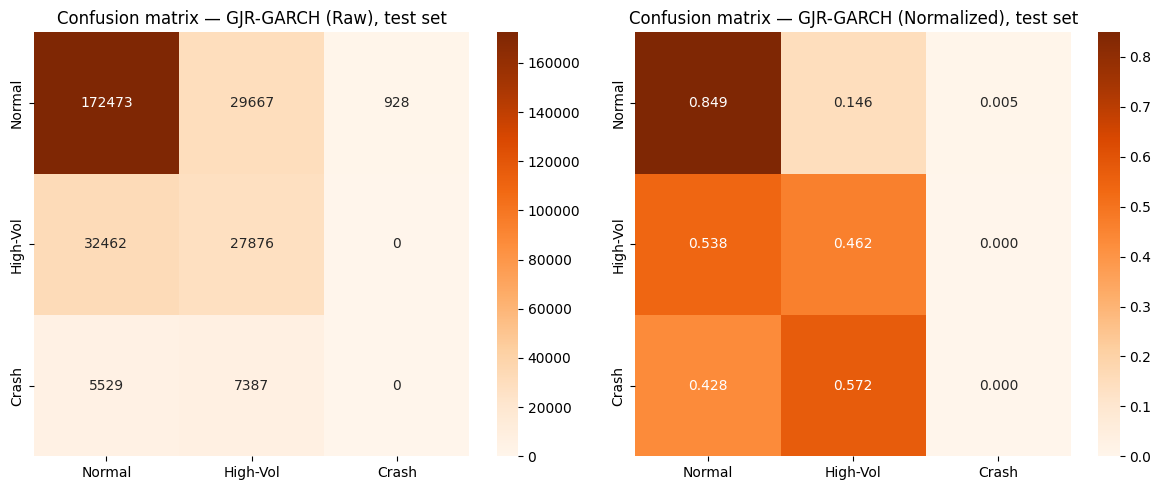


Crash-class PR-AUC : 0.1304
ROC-AUC (OvR)      : 0.7508


In [11]:
# ============================================================
# BLOCK 6-GARCH — TEST-SET CLASSIFICATION REPORT
# ============================================================
print("=== Classification report (test set) — GJR-GARCH ===")
print(classification_report(y_test_garch, test_pred_garch,
                             target_names=[CLASS_NAMES[c] for c in range(3)], digits=4))

cm_garch = confusion_matrix(y_test_garch, test_pred_garch)
cm_garch_norm = confusion_matrix(y_test_garch, test_pred_garch, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_garch, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)], ax=axes[0])
axes[0].set_title("Confusion matrix — GJR-GARCH (Raw), test set")
sns.heatmap(cm_garch_norm, annot=True, fmt=".3f", cmap="Oranges",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)], ax=axes[1])
axes[1].set_title("Confusion matrix — GJR-GARCH (Normalized), test set")
plt.tight_layout(); plt.show()

print(f"\nCrash-class PR-AUC : {crash_pr_auc_garch(y_test_garch, test_proba_garch):.4f}")
print(f"ROC-AUC (OvR)      : {roc_auc_score(y_test_garch, test_proba_garch, multi_class='ovr'):.4f}")

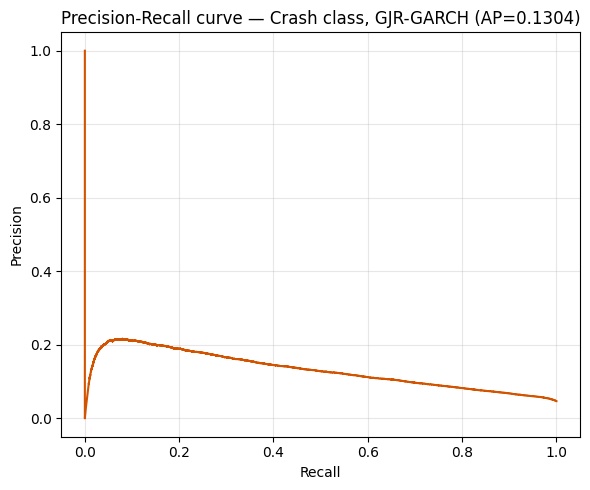

Recall @ FPR<=5%: 0.2271  (threshold=0.0686)
Precision@top-50 alerts: 0.0000
Precision@top-100 alerts: 0.0000
Precision@top-500 alerts: 0.0000
Precision@top-1000 alerts: 0.0440

Event-level crash recall (±1 day tolerance): 0.0000  (10734 distinct crash episodes)


In [12]:
# ============================================================
# BLOCK 7-GARCH — PR CURVE, OPERATIONAL METRICS, EVENT-LEVEL DETECTION
# ============================================================
prec_g, rec_g, _ = precision_recall_curve(y_test_garch == CRASH_IDX, test_proba_garch[:, CRASH_IDX])

plt.figure(figsize=(6, 5))
plt.plot(rec_g, prec_g, color="#d35400")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — Crash class, GJR-GARCH "
          f"(AP={average_precision_score(y_test_garch==CRASH_IDX, test_proba_garch[:,CRASH_IDX]):.4f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

fpr_g, tpr_g, roc_thresh_g = roc_curve(y_test_garch == CRASH_IDX, test_proba_garch[:, CRASH_IDX])
target_fpr = 0.05
idx = max(np.searchsorted(fpr_g, target_fpr, side="right") - 1, 0)
print(f"Recall @ FPR<={target_fpr:.0%}: {tpr_g[idx]:.4f}  (threshold={roc_thresh_g[idx]:.4f})")

for k in [50, 100, 500, 1000]:
    top_k_idx = np.argsort(-test_proba_garch[:, CRASH_IDX])[:k]
    prec_at_k = (y_test_garch[top_k_idx] == CRASH_IDX).mean()
    print(f"Precision@top-{k} alerts: {prec_at_k:.4f}")

def event_level_recall_garch(meta_df, y_true, y_pred, tolerance=1):
    tdf = meta_df.copy()
    tdf["y_true"] = y_true
    tdf["y_pred"] = y_pred
    tdf = tdf.sort_values(["trading_code", "date"]).reset_index(drop=True)

    detected, total_events = 0, 0
    for code, g in tdf.groupby("trading_code"):
        g = g.reset_index(drop=True)
        is_crash = (g["y_true"] == CRASH_IDX).values
        episode_id = (is_crash != np.roll(is_crash, 1)).cumsum() * is_crash
        for eid in np.unique(episode_id[episode_id > 0]):
            idxs = np.where(episode_id == eid)[0]
            total_events += 1
            lo, hi = max(idxs[0]-tolerance, 0), min(idxs[-1]+tolerance, len(g)-1)
            if (g["y_pred"].iloc[lo:hi+1] == CRASH_IDX).any():
                detected += 1
    return detected / total_events if total_events else np.nan, total_events

results_garch["y_pred"] = test_pred_garch
ev_recall_garch, n_events_garch = event_level_recall_garch(
    results_garch[["trading_code","date","y_true"]], y_test_garch, test_pred_garch, tolerance=1)
print(f"\nEvent-level crash recall (±1 day tolerance): {ev_recall_garch:.4f}  ({n_events_garch} distinct crash episodes)")

Brier score (crash)                       : 0.04515
Brier score, prevalence-only baseline     : 0.04456
Brier Skill Score vs. prevalence baseline : -0.0133


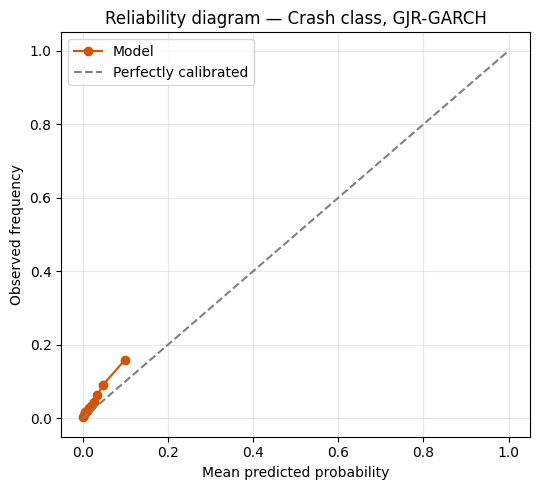

In [13]:
# ============================================================
# BLOCK 8-GARCH — CALIBRATION DIAGNOSTICS
# ============================================================
y_crash_true = (y_test_garch == CRASH_IDX).astype(int)
p_crash_garch = test_proba_garch[:, CRASH_IDX]

brier_garch = brier_score_loss(y_crash_true, p_crash_garch)
prevalence = y_crash_true.mean()
brier_baseline = brier_score_loss(y_crash_true, np.full_like(p_crash_garch, prevalence))
brier_skill_score_garch = 1 - (brier_garch / brier_baseline)

print(f"Brier score (crash)                       : {brier_garch:.5f}")
print(f"Brier score, prevalence-only baseline     : {brier_baseline:.5f}")
print(f"Brier Skill Score vs. prevalence baseline : {brier_skill_score_garch:.4f}")

frac_pos_g, mean_pred_g = calibration_curve(y_crash_true, p_crash_garch, n_bins=10, strategy="quantile")
plt.figure(figsize=(5.5, 5))
plt.plot(mean_pred_g, frac_pos_g, marker="o", color="#d35400", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Reliability diagram — Crash class, GJR-GARCH")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [14]:
# ============================================================
# BLOCK 9-GARCH — REGIME-SPECIFIC PERFORMANCE
# ============================================================
REGIMES = {
    "Pre-COVID (2019)":        ("2019-01-01", "2020-02-29"),
    "COVID crash":              ("2020-03-01", "2020-05-31"),
    "Post-COVID recovery":      ("2020-06-01", "2021-12-31"),
    "Russia-Ukraine (2022)":    ("2022-02-24", "2022-12-31"),
}

results_garch["y_pred"] = test_pred_garch
results_garch["p_crash"] = test_proba_garch[:, CRASH_IDX]

regime_rows_garch = []
for name, (start, end) in REGIMES.items():
    mask = (results_garch["date"] >= start) & (results_garch["date"] <= end)
    sub = results_garch[mask]
    if len(sub) == 0:
        continue
    y_true_r, y_pred_r, p_r = sub["y_true"], sub["y_pred"], sub["p_crash"]
    regime_rows_garch.append({
        "regime": name, "n_rows": len(sub),
        "crash_rate": (y_true_r == CRASH_IDX).mean(),
        "crash_recall": recall_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_pr_auc": average_precision_score(y_true_r == CRASH_IDX, p_r) if (y_true_r==CRASH_IDX).sum() > 0 else np.nan,
    })

regime_df_garch = pd.DataFrame(regime_rows_garch).set_index("regime")
print(regime_df_garch.round(4))

                       n_rows  crash_rate  crash_recall  crash_precision  \
regime                                                                     
Pre-COVID (2019)        83685      0.0511           0.0              0.0   
COVID crash              5636      0.2284           0.0              0.0   
Post-COVID recovery    115284      0.0475           0.0              0.0   
Russia-Ukraine (2022)   60472      0.0255           0.0              0.0   

                       crash_pr_auc  
regime                               
Pre-COVID (2019)             0.1133  
COVID crash                  0.2485  
Post-COVID recovery          0.1274  
Russia-Ukraine (2022)        0.1267  


GJR-GARCH PARAMETER SUMMARY ACROSS ALL FITTED TICKERS
          alpha     gamma      beta  persistence        nu
count  300.0000  300.0000  300.0000     300.0000  300.0000
mean     0.1382   -0.0129    0.8028       0.9345  321.0311
std      0.0560    0.0515    0.1059       0.0845  120.6494
min      0.0043   -0.5107    0.0000       0.2190    2.4251
25%      0.1103   -0.0275    0.7809       0.9313  228.9331
50%      0.1326   -0.0091    0.8213       0.9502  316.8380
75%      0.1553    0.0080    0.8528       0.9658  413.0462
max      0.7189    0.1842    0.9945       1.0000  500.0000

Tickers with significant leverage effect (gamma > 0): 34.7%
Mean volatility persistence (alpha+gamma/2+beta): 0.9345
Mean degrees of freedom (Student-t, lower = fatter tails): 321.03


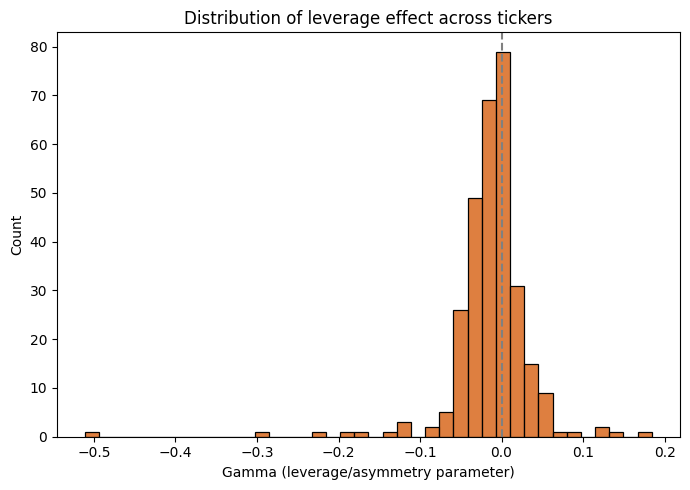

In [15]:
# ============================================================
# BLOCK 10-GARCH — PARAMETER INTERPRETATION
# GARCH has no feature-importance analogue, but the fitted parameters
# themselves are directly interpretable: alpha (shock sensitivity), gamma
# (leverage/asymmetry — positive means negative returns raise volatility
# more), beta (volatility persistence), and overall persistence
# (alpha + gamma/2 + beta, must be <1 for stationarity).
# ============================================================
param_df = pd.DataFrame(ticker_models).T
param_df.index.name = "trading_code"
param_df = param_df.astype(float)

print("="*70)
print("GJR-GARCH PARAMETER SUMMARY ACROSS ALL FITTED TICKERS")
print("="*70)
print(param_df[["alpha","gamma","beta","persistence","nu"]].describe().round(4))

print(f"\nTickers with significant leverage effect (gamma > 0): "
      f"{(param_df['gamma'] > 0).mean():.1%}")
print(f"Mean volatility persistence (alpha+gamma/2+beta): {param_df['persistence'].mean():.4f}")
print(f"Mean degrees of freedom (Student-t, lower = fatter tails): {param_df['nu'].mean():.2f}")

plt.figure(figsize=(7, 5))
sns.histplot(param_df["gamma"], bins=40, color="#d35400")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Gamma (leverage/asymmetry parameter)")
plt.title("Distribution of leverage effect across tickers")
plt.tight_layout(); plt.show()

In [16]:
# ============================================================
# BLOCK 11-GARCH — SUMMARY TABLE
# ============================================================
summary_garch = pd.DataFrame({
    "Model": ["GJR-GARCH(1,1), Student-t"],
    "Crash PR-AUC": [crash_pr_auc_garch(y_test_garch, test_proba_garch)],
    "Crash Recall": [recall_score(y_test_garch==CRASH_IDX, test_pred_garch==CRASH_IDX)],
    "Crash Precision": [precision_score(y_test_garch==CRASH_IDX, test_pred_garch==CRASH_IDX, zero_division=0)],
    "ROC-AUC (OvR)": [roc_auc_score(y_test_garch, test_proba_garch, multi_class="ovr")],
    "Brier Skill Score": [brier_skill_score_garch],
    "Event-level recall (±1d)": [ev_recall_garch],
    "Tickers fitted": [len(ticker_models)],
    "Tickers skipped": [len(skipped_tickers)],
})
print(summary_garch.round(4))

                       Model  Crash PR-AUC  Crash Recall  Crash Precision  \
0  GJR-GARCH(1,1), Student-t        0.1304           0.0              0.0   

   ROC-AUC (OvR)  Brier Skill Score  Event-level recall (±1d)  Tickers fitted  \
0         0.7508            -0.0133                       0.0             300   

   Tickers skipped  
0               11  


1. CLASSIFICATION REPORT (test set) — GJR-GARCH
              precision  recall  f1-score      support
Normal           0.8195  0.8493    0.8341  203068.0000
High-Vol         0.4293  0.4620    0.4451   60338.0000
Crash            0.0000  0.0000    0.0000   12916.0000
accuracy         0.7251  0.7251    0.7251       0.7251
macro avg        0.4163  0.4371    0.4264  276322.0000
weighted avg     0.6960  0.7251    0.7102  276322.0000

2. CROSS-VALIDATION REPORT (mean ± std across folds) — GJR-GARCH
              precision_mean  precision_std  recall_mean  recall_std  \
class_metric                                                           
Crash                 0.0169         0.0378       0.0010      0.0022   
High-Vol              0.3966         0.0174       0.3209      0.0723   
Normal                0.8012         0.0605       0.8929      0.0524   
accuracy              0.7375         0.0769       0.7375      0.0769   
macro avg             0.4049         0.0152       0.4049      0.0087 

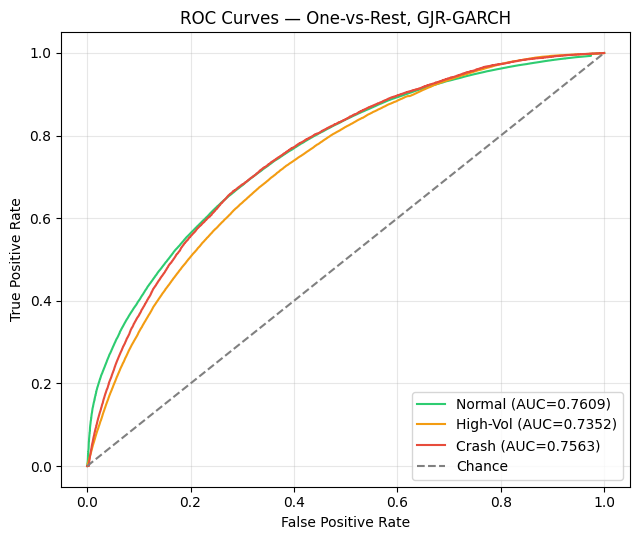


REPORT COMPLETE — GJR-GARCH


In [17]:
# ============================================================
# BLOCK 12-GARCH — FINAL COMPREHENSIVE REPORT (reuses Block 5 fold results)
# ============================================================
CLASS_ORDER = [0, 1, 2]
CLASS_LABELS_LIST = [CLASS_NAMES[c] for c in CLASS_ORDER]

print("="*70)
print("1. CLASSIFICATION REPORT (test set) — GJR-GARCH")
print("="*70)
report_dict_garch = classification_report(y_test_garch, test_pred_garch, target_names=CLASS_LABELS_LIST,
                                           digits=4, output_dict=True)
print(pd.DataFrame(report_dict_garch).T.round(4))

print("\n" + "="*70)
print("2. CROSS-VALIDATION REPORT (mean ± std across folds) — GJR-GARCH")
print("="*70)
per_fold_reports_garch = []
for fold_result in fold_val_predictions_garch:
    rep = classification_report(fold_result["y_va"], fold_result["pred"], target_names=CLASS_LABELS_LIST,
                                 digits=4, output_dict=True, zero_division=0)
    rep_df = pd.DataFrame(rep).T
    rep_df["fold"] = fold_result["fold"]
    per_fold_reports_garch.append(rep_df)

all_folds_df_garch = pd.concat(per_fold_reports_garch).reset_index().rename(columns={"index": "class_metric"})
cv_summary_garch = all_folds_df_garch.groupby("class_metric")[["precision", "recall", "f1-score", "support"]].agg(["mean", "std"])
cv_summary_garch.columns = ["_".join(c) for c in cv_summary_garch.columns]
print(cv_summary_garch.round(4))

y_test_bin = label_binarize(y_test_garch, classes=CLASS_ORDER)
plt.figure(figsize=(6.5, 5.5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for i, c in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba_garch[:, i])
    roc_auc_c = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{CLASS_NAMES[c]} (AUC={roc_auc_c:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest, GJR-GARCH")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*70)
print("REPORT COMPLETE — GJR-GARCH")
print("="*70)